In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import power_transform


#import lissa as li

In [2]:
n = 500
tf = 10
t = np.linspace(0,tf,n)

In [3]:
window = np.exp((-(t-tf/2)*(t-tf/2))/0.3)

X = np.array(
    [
        np.sin(40*t)*window,
        np.sin(10*t+np.pi/4)*window,
        np.sin(5*t*t),
        np.ones(n)*window
    ]
)

nc = X.shape[0]


noiseamp = 0.05*np.max(X)
noise = noiseamp*np.random.randn(nc,n)


Q = np.linalg.qr(np.random.rand(nc,nc)).Q



S = pd.DataFrame(X.T@Q,columns=["new 0","new 1","new 2","new 3"])
Sn = (S+noise.T)
Z = Sn.ewm(alpha=0.8).mean()#((S-S.expanding().mean())/S.expanding().std()).fillna(0)

#Z.plot()

model = PCA(n_components=4)
recover = model.fit_transform(Z)
model.components_

array([[-0.31157089,  0.74585818, -0.49309294,  0.32168075],
       [-0.81203794, -0.43531024,  0.09974414,  0.3757    ],
       [-0.49119351,  0.20196298,  0.06471199, -0.84483859],
       [ 0.04740151, -0.46196485, -0.86181368, -0.20400676]])

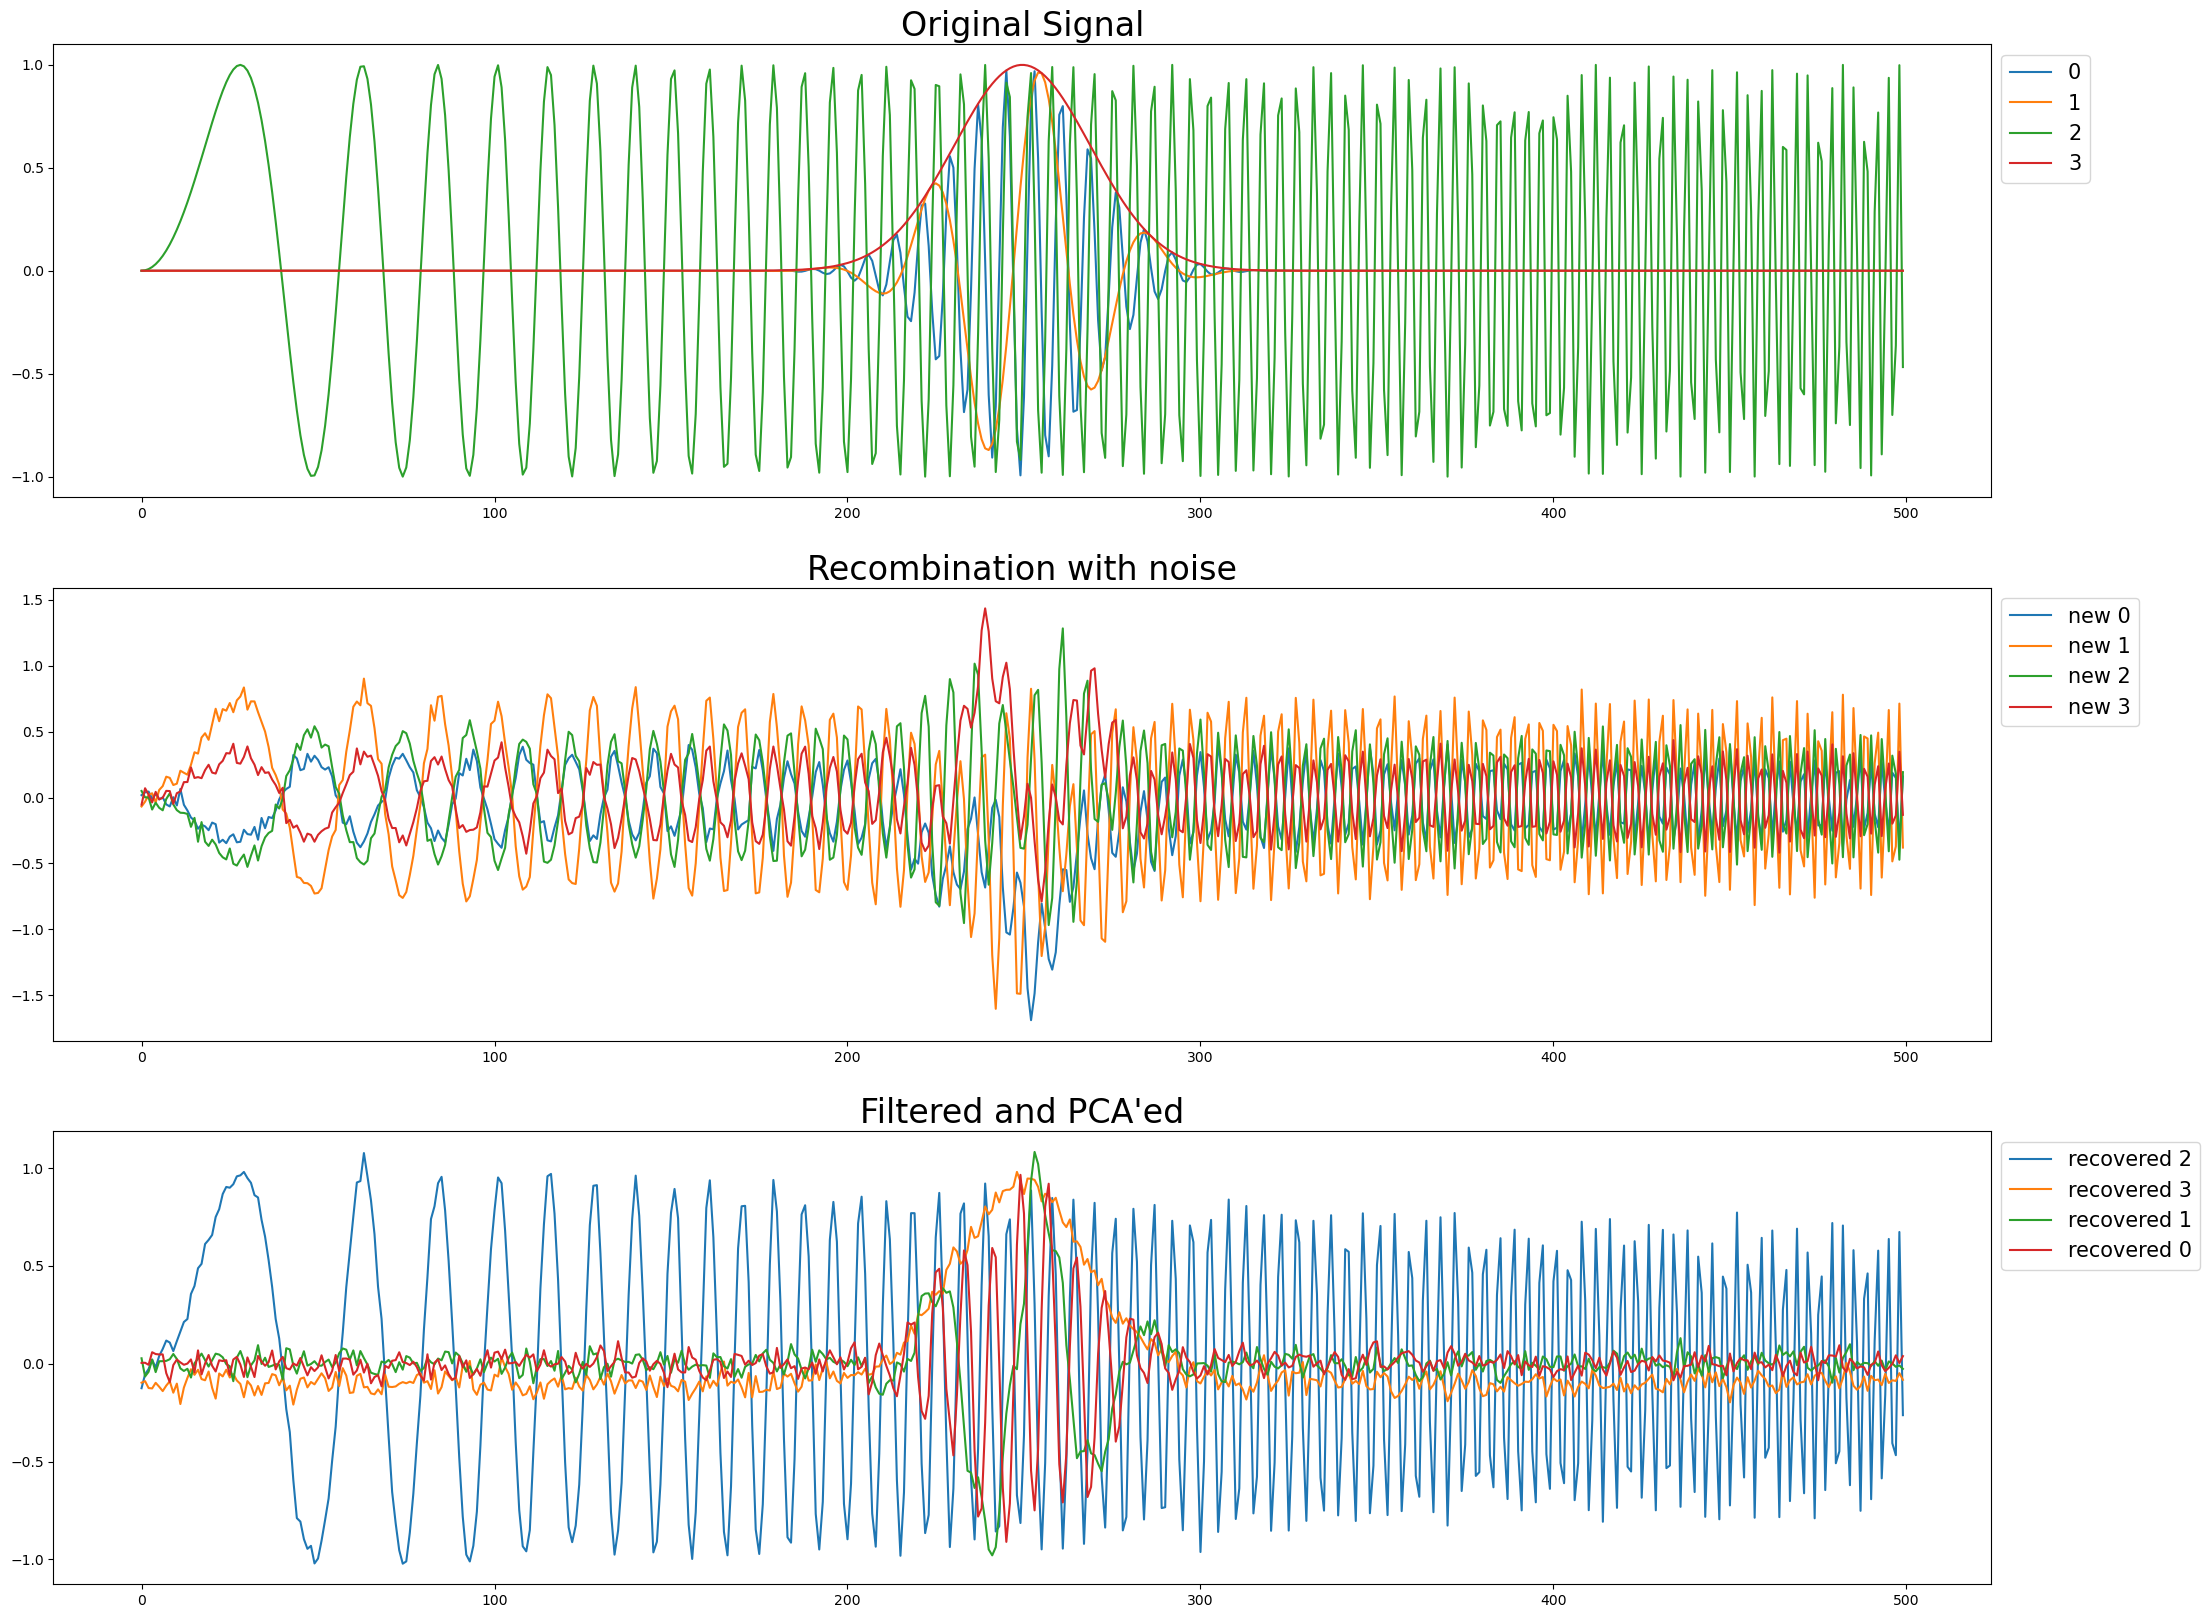

In [4]:
fig, axs = plt.subplots(3,1)
plt.rcParams.update({'font.size': 20})

pd.DataFrame(X.T).plot(ax=axs[0])

Sn.plot(ax=axs[1],figsize=(25,20))



recover = pd.DataFrame(recover,columns=["recovered 2","recovered 3","recovered 1","recovered 0"])

recover.plot(ax=axs[2])

axs[0].set_title("Original Signal")
axs[1].set_title("Recombination with noise")
axs[2].set_title("Filtered and PCA'ed")




axs[0].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[1].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[2].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)




array([[<AxesSubplot: title={'center': 'recovered 2'}>,
        <AxesSubplot: title={'center': 'recovered 3'}>],
       [<AxesSubplot: title={'center': 'recovered 1'}>,
        <AxesSubplot: title={'center': 'recovered 0'}>]], dtype=object)

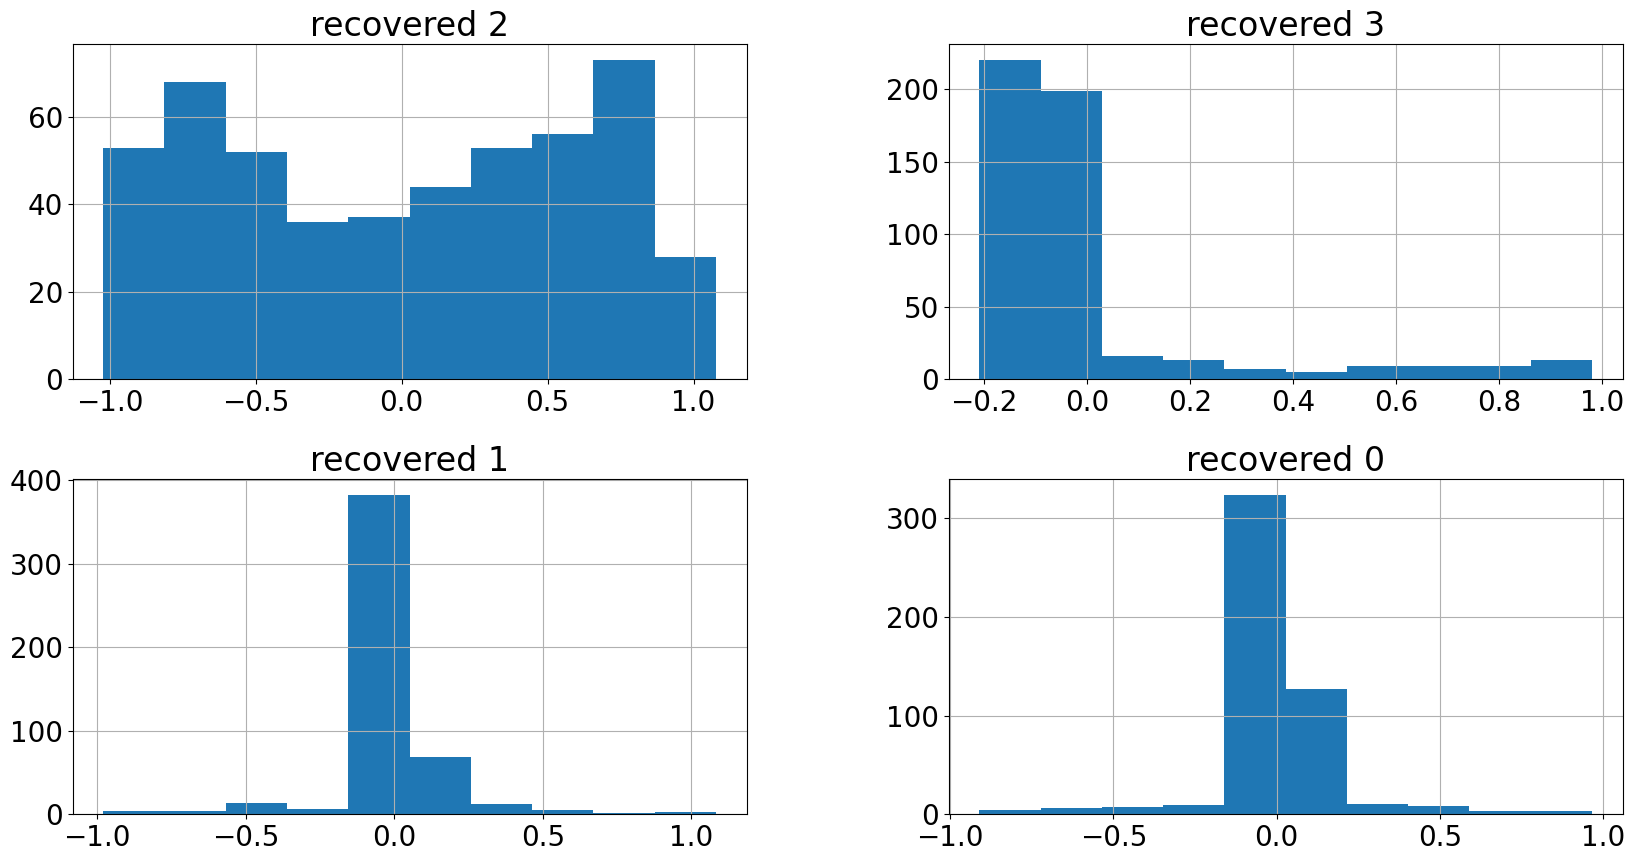

In [5]:
recover.hist(figsize=(20,10))

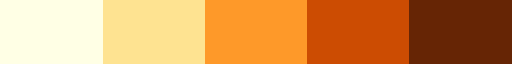

In [6]:
# Exemplo de estados ao longo do tempo
n = 4
states = range(0,n+1)

# Gerando cores automáticas com base no número de estados
num_states = len(np.unique(states))
cmap = plt.get_cmap('YlOrBr', num_states)  # Escolhe um colormap com num_states cores

cmap

In [7]:
squared = recover.pow(2).sum(axis=1).pow(1/2)

model = GaussianHMM(n_components=n,covariance_type="full",random_state=np.random.seed(19971215))
model.fit(squared.to_numpy().reshape(-1,1))

states = model.predict(squared.to_numpy().reshape(-1,1))

final = pd.DataFrame(np.array([squared, states]).T,columns=["Square","STS"])


Text(0.5, 1.0, 'Hidden Markov applied to norm-2 PCA components')

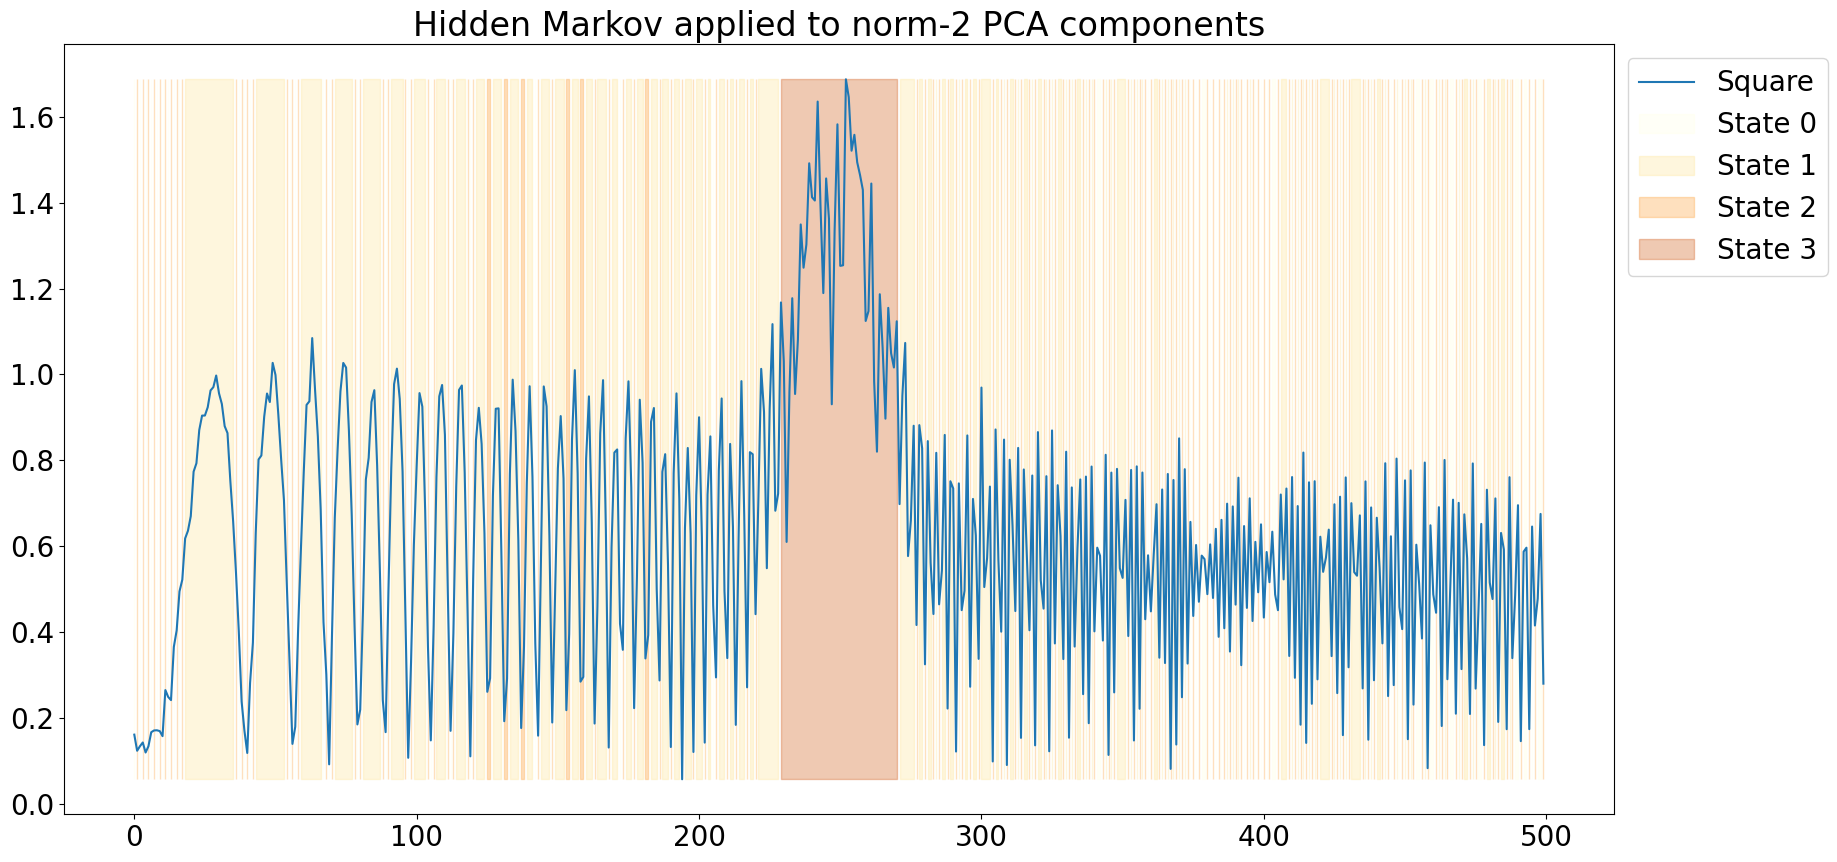

In [8]:
fig,axs = plt.subplots(1,1)
final["Square"].plot(ax=axs,figsize=(20,10))


for state in range(0,n):
            color = cmap(state)  # Pega uma cor automática para cada estado
            axs.fill_between(final.index,np.min(squared), np.max(squared), where=(final["STS"] == state), 
                            color=color, alpha=0.3, label=f"State {state}")

            axs.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=20)

plt.title("Hidden Markov applied to norm-2 PCA components")


In [9]:
print(model.get_stationary_distribution())

[0.18444208 0.43817751 0.29384103 0.08353938]


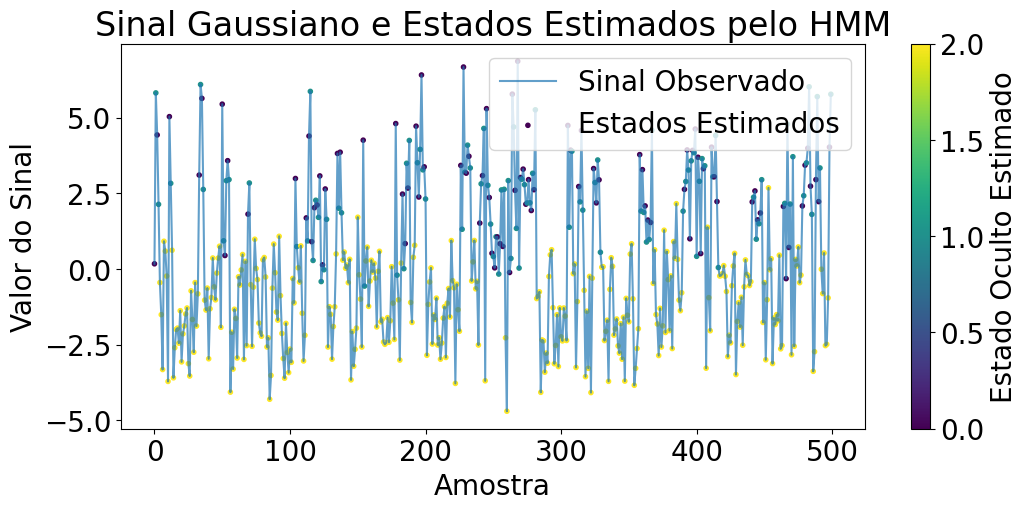

In [10]:
import numpy as np
import matplotlib.pyplot as plt


# Definição dos estados ocultos
np.random.seed(42)
n_samples = 500  

# Definição das distribuições dos estados
means = [-2, 0, 3]  # Médias dos estados
std_devs = [1, 0.5, 1.5]  # Desvios padrão dos estados
transition_matrix = [[0.8, 0.1, 0.1], 
                     [0.2, 0.6, 0.2], 
                     [0.1, 0.2, 0.7]]

# Simulação da sequência de estados
states = [np.random.choice([0, 1, 2], p=[1/3, 1/3, 1/3])]
for _ in range(n_samples - 1):
    states.append(np.random.choice([0, 1, 2], p=transition_matrix[states[-1]]))

# Geração do sinal baseado nos estados ocultos
signal = np.array([np.random.normal(means[s], std_devs[s]) for s in states]).reshape(-1, 1)

# Ajuste do modelo HMM
hmm = GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
hmm.fit(signal)

# Predição dos estados ocultos
predicted_states = hmm.predict(signal)

# Plotando o sinal e os estados estimados
plt.figure(figsize=(12, 5))
plt.plot(signal, label="Sinal Observado", alpha=0.7)
plt.scatter(range(n_samples), signal, c=predicted_states, cmap="viridis", marker='.', label="Estados Estimados")
plt.colorbar(label="Estado Oculto Estimado")
plt.xlabel("Amostra")
plt.ylabel("Valor do Sinal")
plt.title("Sinal Gaussiano e Estados Estimados pelo HMM")
plt.legend()
plt.show()

